# **PROJETO AVALIATIVO - MÓDULO 1**

**Aluno:** Otávio Augusto Reis Nascimento

**Projeto:** GearGuard

**Professor:** Lucas Ribeiro de Lima

# **1. Inspecionando dados**

Carregando o DF

In [ ]:
import pandas as pd

df = pd.read_csv('/content/manutencao_preditiva.csv')

Verifica o número de colunas e linhas

In [3]:
print(f"Shape do DataFrame: {df.shape}")

Shape do DataFrame: (10000, 14)


Informações sobre as colunas e tipos de dados:

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

None

Validação dos tipos de dados:

In [19]:
display(df.dtypes)

,0
udi,int64
id_produto,object
tipo,object
temperatura_ar_k,float64
temperatura_processo_k,float64
velocidade_rotacao_rpm,float64
torque_nm,float64
desgaste_ferramenta_min,int64
falha_maquina,int64
falha_twf,int64


Contagem de valores nulos por coluna

In [20]:
display(df.isnull().sum())

,0
udi,0
id_produto,0
tipo,0
temperatura_ar_k,500
temperatura_processo_k,500
velocidade_rotacao_rpm,500
torque_nm,500
desgaste_ferramenta_min,0
falha_maquina,0
falha_twf,0


Foi encontrado 500 valores nulos mas colunas: temperatura_ar_k, Temperatura_processo_k, velocidade_rotacao_rpm e torque_nm

Verifica os 10 primeiros registros do DF pra visualizar melhor a "sujeira".

In [7]:
display(df.head(10))

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558.0,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527.0,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667.0,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741.0,28.0,21,0,0,0,0,0,0


Utilizando o describe() para identificar anomalias, como valores fora da faixa e a proximidade entre média e mediana para verifcar possíveis outliers.

In [11]:
display(df.describe())

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Com as informações obtidas dos valores nulos nas colunas temperatura_ar_k, Temperatura_processo_k, velocidade_rotacao_rpm e torque_nm demonstra um ponto importante a ser analisado, pois essas métricas são importantes para entender o desempenho e saúde dos equipamentos. Esses valores ausentes podem comprometer a precisão de qualquer análise preditiva.

Vou realizar a importação do matplotlib e do seaborn, definir as variáveis preditoras para o histograma e criar os gráficos em seguida.

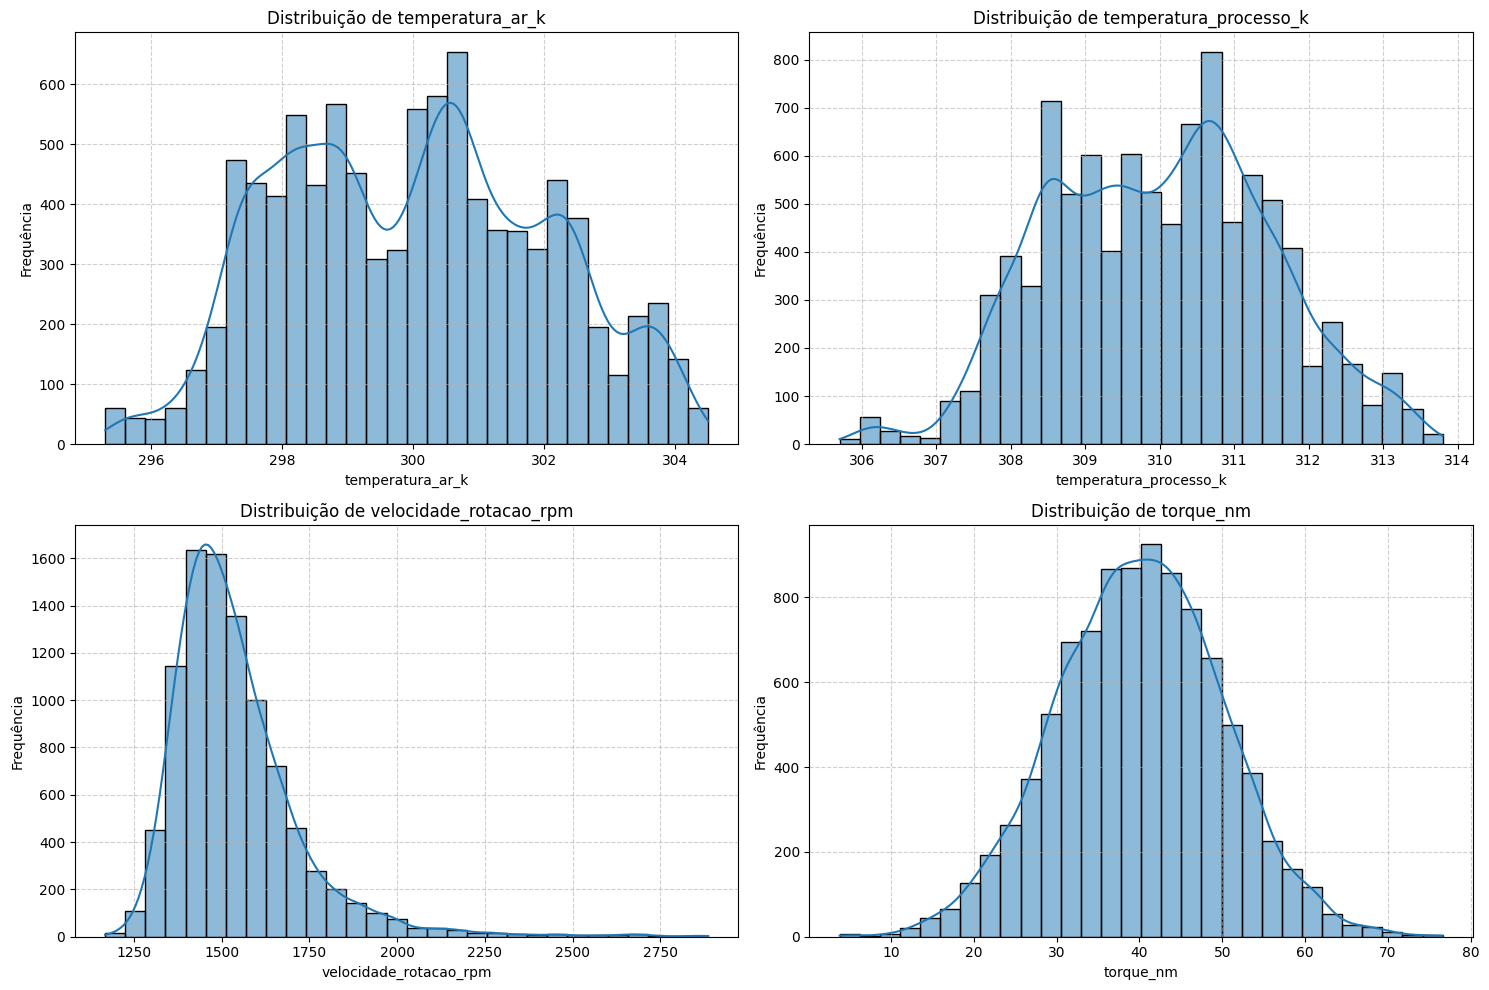

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


preditoras_vars = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(preditoras_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Agora irei verificar a Taxa de Desbalanceamento da Variávelalvo. A variável alvo **falha_maquina** (indica se houve falha mecânica ou não) é crucial para o modelo. É fundamental verificar se há um desbalanceamento significativo entre as classes (0: sem falha, 1: com falha), pois isso pode impactar no treinamento do modelo.



/tmp/ipykernel_1712/1916437982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='falha_maquina', data=df, palette='viridis')


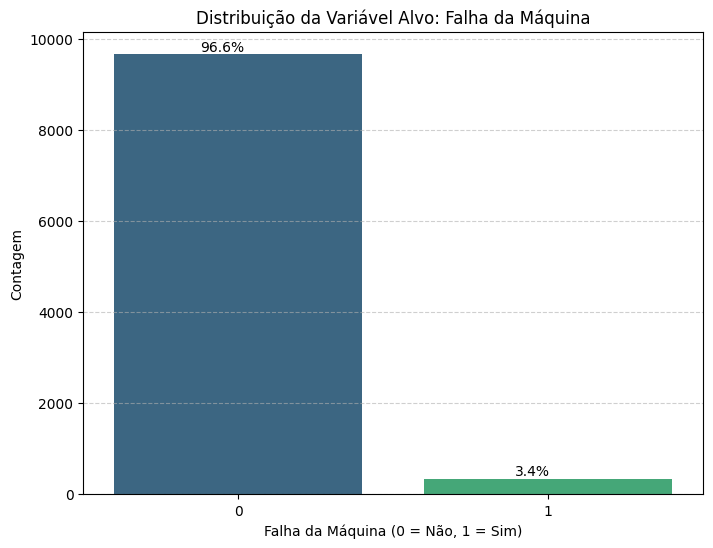

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(x='falha_maquina', data=df, palette='viridis')
plt.title('Distribuição da Variável Alvo: Falha da Máquina')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Contagem')

total = len(df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas

O mapa de calor da matriz de correlação de Pearson me mostra o quanto duas variáveis se parecem no jeito que se comportam. Por exemplo, cores fortes (positiva ou negativa) significa que existe uma relação clara, quando uma aumenta a outra, também aumenta, ou então, quando uma sobe a outra desce.

As cores mais claras vão indicar que não possuem muita ligação, que cada variável segue seu caminho sem depender da outra.

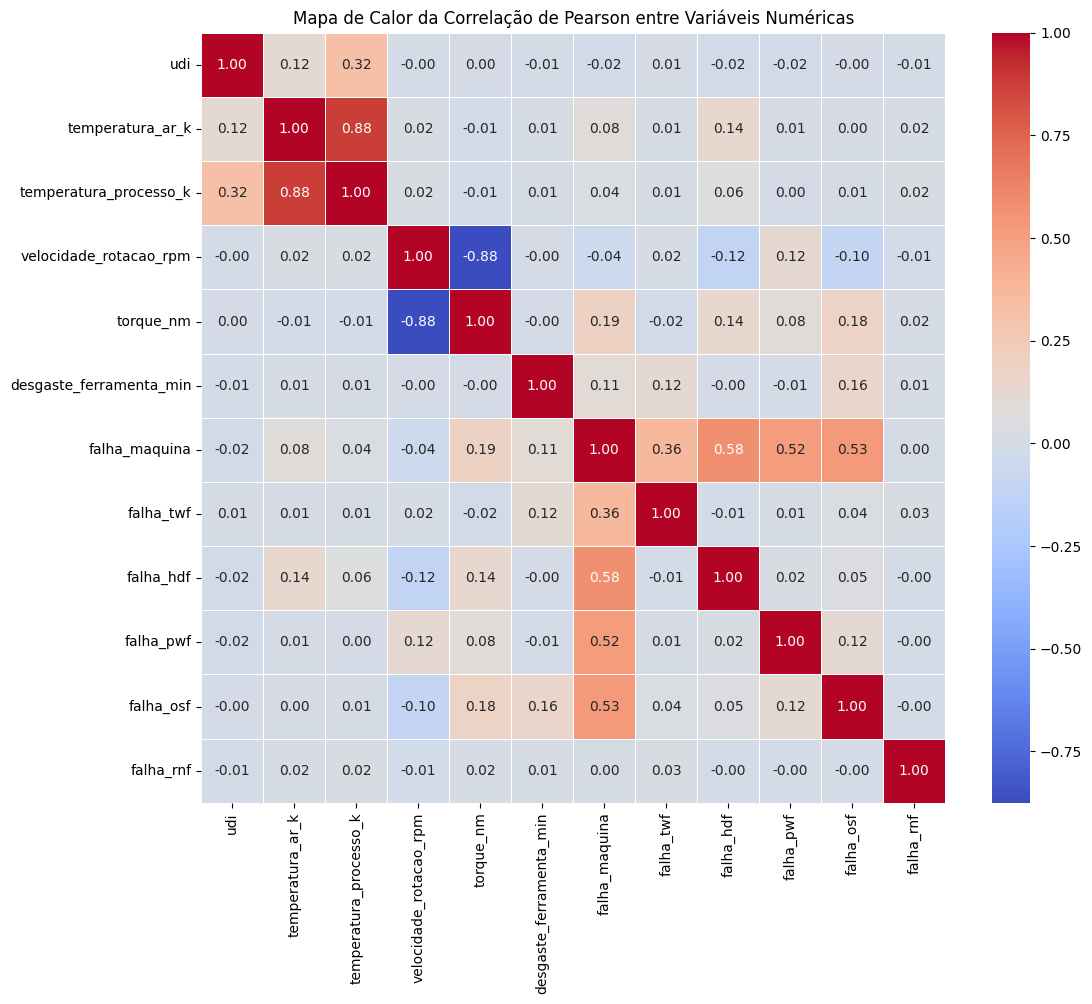

In [16]:
correlacao_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacao_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas')
plt.show()

# **1.1 Resultado da exploração de dados**

**Explicação do resultado:** Os dados ausentes precisam de atenção imediata, será necessario verificar se vou imputar dados ou remove-los para garantir uma integridade das análises e modelos. Os resultados demonstram que as Altas temperaturas andam juntas, ou seja, o ambiente afeta o processo. Já a velocidade e torque são opostos, porque para ter mais força (torque), geralmente a velocidade diminui e para mais velocidade a força pode ser menor. As falhas e as outras variáveis possuem correlações com as outras falhas, que também possuem uma relação com o desgaste_ferramenta_min e com a temperatura_processo_k o que podem ter uma relação na ocorrência de falhas.
**Resumindo:** É necessário tratar os dados faltantes, corrigir o desbalanceamento e considerar as relações entre variáveis para garantir que os modelos sejam confiáveis e focados em prever o que realmente importa: **as falhas.**